### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/tmp/ipykernel_463831/767131013.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


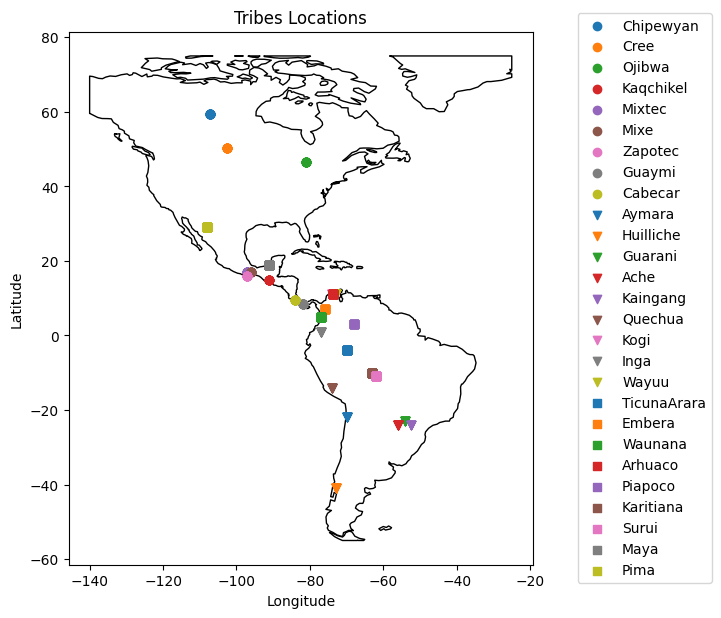

In [1]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [4]:
import numpy as np
# Prepare design matrix and target
predictors = df.columns[8:]
X = df[predictors].values.astype(float)   # shape (494, 5709)
y = df['long'].values

print(f"X shape: {X.shape}, rank: {np.linalg.matrix_rank(X)}")

# Attempt to solve (X^T X) beta = X^T y  via numpy.linalg.solve
try:
    XtX  = X.T @ X
    Xty  = X.T @ y
    beta = np.linalg.solve(XtX, Xty)
    print("Solution found (unexpected).")
except np.linalg.LinAlgError as e:
    print(f"LinAlgError raised: {e}")

X shape: (494, 5709), rank: 494
LinAlgError raised: Singular matrix


**Answer:** `numpy.linalg.solve` raises a `LinAlgError: Singular matrix` error. This is expected because $X \in \mathbb{R}^{N \times p}$ with $N = 494 < p = 5709$, so $\text{rank}(X) \leq N < p$. Therefore $X^\top X \in \mathbb{R}^{p \times p}$ is **singular** (rank-deficient): its determinant is zero, it is not invertible, and the system $X^\top X \hat\beta = X^\top y$ has infinitely many solutions. `numpy.linalg.solve` requires the matrix to be square *and* invertible, so it fails.


**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [5]:
# Use lstsq to find the minimum-norm least-squares solution
beta_lstsq, residuals, rank, sv = np.linalg.lstsq(X, y, rcond=None)
print(f"beta_lstsq shape: {beta_lstsq.shape}")
print(f"First 5 coefficients: {beta_lstsq[:5]}")
print(f"Effective rank of X: {rank}")

beta_lstsq shape: (5709,)
First 5 coefficients: [-0.04005781 -0.01940898  0.01111306 -0.01234685 -0.02460976]
Effective rank of X: 494


Answer: No error is raised. numpy.linalg.lstsq does not require the matrix to be invertible. Instead of solving the square system 𝑋⊤𝑋𝛽̂ =𝑋⊤𝑦, it directly minimises ‖𝑋𝛽−𝑦‖22 using the Singular Value Decomposition (SVD) of 𝑋. When the system is underdetermined (more unknowns than equations, or rank-deficient), it returns the minimum-norm solution among all least-squares solutions, without needing 𝑋⊤𝑋 to be invertible. This is in contrast to numpy.linalg.solve, which expects a full-rank square system.


 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [6]:
from sklearn.linear_model import LinearRegression

# select only the genetic markers as predictors
predictors = df.columns[8:]
X = df[predictors].values
y = df['long'].values

# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)

print("sklearn coef (first 5):", lr.coef_[:5])
print("lstsq  coef (first 5):", beta_lstsq[:5])
print("\nCoefficients are the same?", np.allclose(lr.coef_, beta_lstsq))

sklearn coef (first 5): [-0.03940988 -0.0245272   0.01089763  0.01066482 -0.02470103]
lstsq  coef (first 5): [-0.04005781 -0.01940898  0.01111306 -0.01234685 -0.02460976]

Coefficients are the same? False


**Answer:** The coefficients from `sklearn` differ from those obtained with `numpy.linalg.lstsq`. This is because sklearn **re-centers** the predictors by subtracting their column means before fitting, i.e. it works with $\tilde{X} = X - \bar{X}$ instead of $X$. The practical reason for this is to ensure the **intercept is interpretable**: when predictors are centred, the intercept $\hat\beta_0$ equals the mean of the response $\bar{y}$, which is the prediction when all predictors take their average value. Without centring, the intercept conflates the mean effects of all predictors and becomes harder to interpret. It also improves numerical stability.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

**Principal Component Analysis (PCA)** is a dimensionality-reduction technique that finds a new coordinate system for the data.

**Geometric interpretation:** PCA finds the orthogonal directions (principal components) along which the data points are most spread out. The first principal component (PC1) is the direction of maximum variance; PC2 is orthogonal to PC1 and captures the next highest variance, and so on. The data can then be projected onto a low-dimensional subspace spanned by the first $k$ principal components, which provides the best rank-$k$ linear approximation of the original data (in the least-squares sense, by the Eckart–Young theorem).

**Statistical interpretation:** PCA decomposes the covariance matrix $\Sigma = \frac{1}{N} X^\top X$ (for centred $X$) into its eigenvectors and eigenvalues. The eigenvectors are the principal components and the corresponding eigenvalues measure the variance explained along each direction. PCA thus identifies the latent axes of maximum variability and removes redundant, correlated features by projecting onto the uncorrelated principal components.

In practice, PCA is computed via the SVD of the centred data matrix: $X = U \Sigma V^\top$, where the columns of $V$ are the principal directions (loadings), $\Sigma$ contains the singular values, and $U\Sigma$ gives the scores (projected coordinates) of each data point in the new basis.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

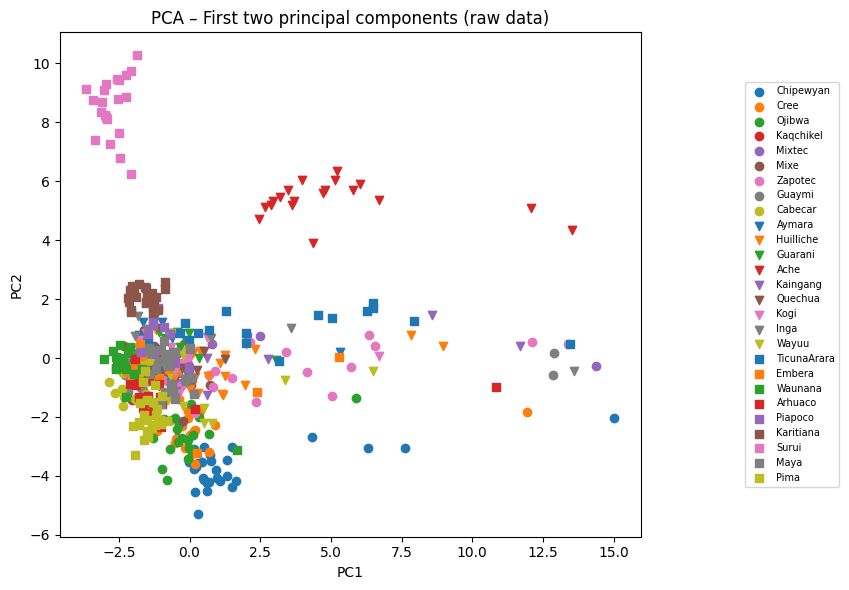

In [7]:
from sklearn.decomposition import PCA

# Prepare data
predictors = df.columns[8:]
X = df[predictors].values.astype(float)

# Fit PCA (full, we'll reuse later)
pca = PCA()
pca.fit(X)
X_pca = pca.transform(X)

# 2D scatter plot on first two PCs
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

fig, ax = plt.subplots(figsize=(9, 6))
for i, tribe in enumerate(df['Pop'].unique()):
    idx = df['Pop'] == tribe
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               marker=marker_list[i // 9],
               color=colors_list[i % 9], label=tribe)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA – First two principal components (raw data)')
ax.legend(loc='center right', bbox_to_anchor=(1.35, 0.5), fontsize=7)
plt.tight_layout()
plt.show()

The 2D projection reveals a clear structure: tribes from different regions of the Americas tend to cluster together, indicating that genetic variation carries strong geographical signal. Some tribes overlap, likely those from geographically proximate regions.

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

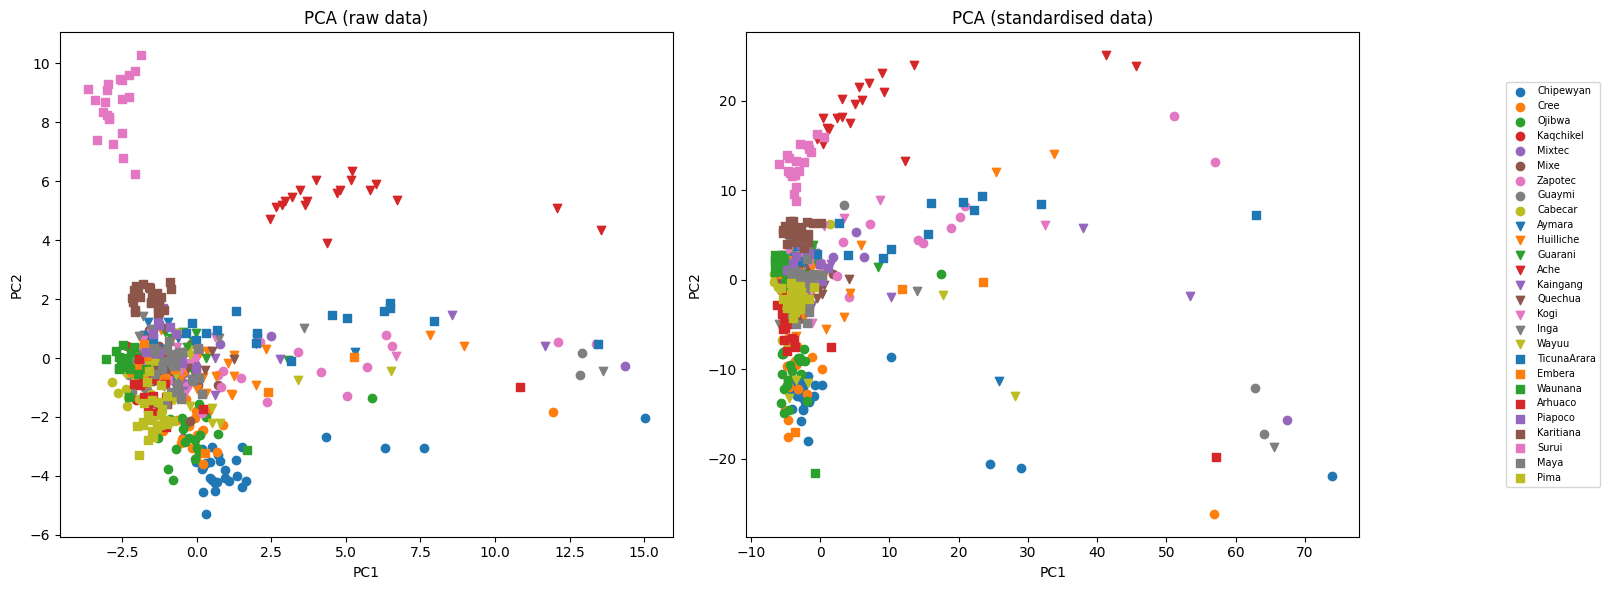

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

pca_std = PCA()
pca_std.fit(X_std)
X_pca_std = pca_std.transform(X_std)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, scores, title in zip(axes,
                              [X_pca, X_pca_std],
                              ['PCA (raw data)', 'PCA (standardised data)']):
    for i, tribe in enumerate(df['Pop'].unique()):
        idx = df['Pop'] == tribe
        ax.scatter(scores[idx, 0], scores[idx, 1],
                   marker=marker_list[i // 9],
                   color=colors_list[i % 9], label=tribe)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title)

axes[1].legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize=7)
plt.tight_layout()
plt.show()

The two scatter plots look very similar. The cluster structure is preserved in both cases, with comparable separations between tribal groups.

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

**Standardisation is not necessary** for this dataset. All genetic markers are binary variables encoded as 0 or 1, so they are already on the same scale. Standardising is important when features have very different variances or units (e.g. mixing a variable in millimetres with one in kilograms), because otherwise PCA would be dominated by high-variance features. Here, since all features share the same domain and encoding, the two PCA projections are essentially equivalent. We will proceed with the raw (non-standardised) data.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

In [ ]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"Variance explained by PC1: {100*explained_variance_ratio[0]:.2f}%")
print(f"Variance explained by PC2: {100*explained_variance_ratio[1]:.2f}%")
print(f"Variance explained by PC1+PC2: {100*cumulative_variance[1]:.2f}%")

# Find how many PCs are needed to explain 95% of variance
n_95 = np.searchsorted(cumulative_variance, 0.95) + 1
print(f"\nNumber of PCs to explain 95% of variance: {n_95}")

# Plot cumulative explained variance
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, len(cumulative_variance) + 1), 100 * cumulative_variance,
        linewidth=1.5, coseelor='steelblue')
ax.axhline(95, color='red', linestyle='--', label='95% threshold')
ax.axvline(n_95, color='orange', linestyle='--', label=f'PC {n_95}')
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('Cumulative explained variance vs. number of principal components')
ax.legend()
ax.set_xlim(0, 494)
plt.tight_layout()
plt.show()

The first two principal components explain a modest fraction of the total variance (see printed output above). To reach 95% of explained variance, approximately **n_95** components are needed (see the orange vertical line on the plot). The cumulative variance curve rises quickly at first (the first few PCs capture the dominant structure) but flattens progressively, showing that many components are needed to represent all the genetic variability. For the purpose of regression, we do not necessarily need to explain 95% of variance; we need enough components to capture the variation that is predictive of geographical location.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

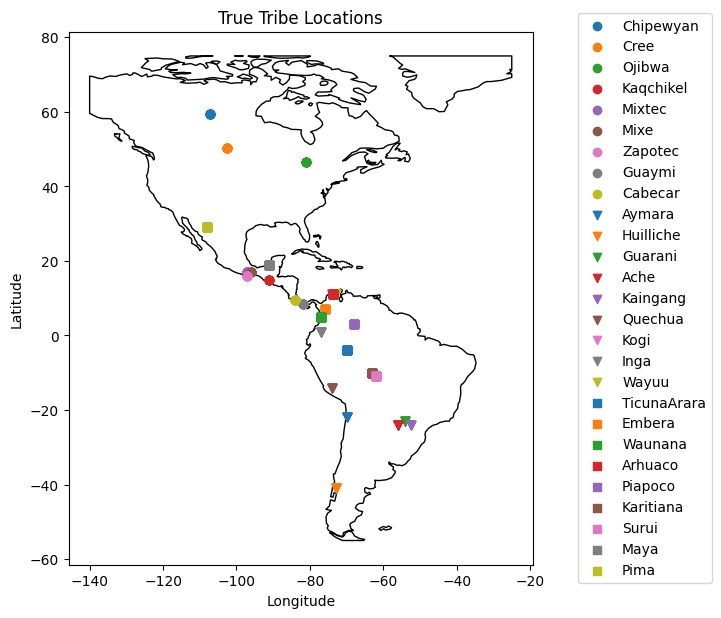

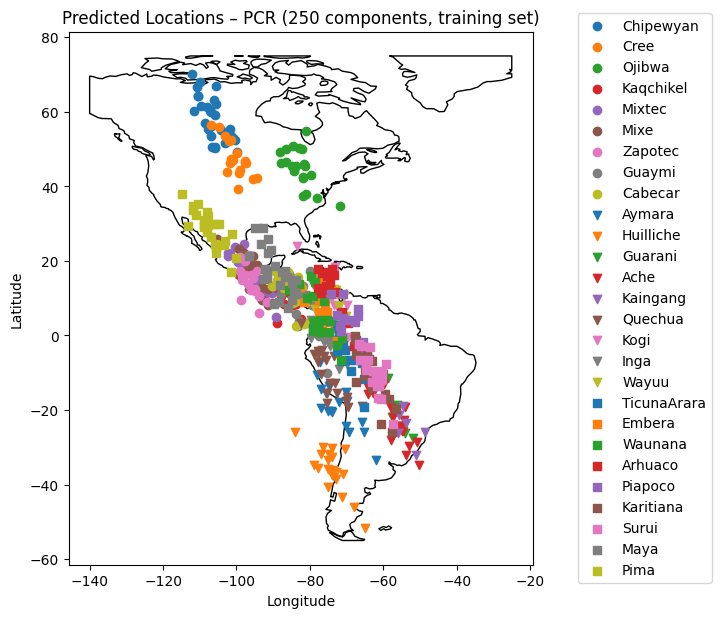

In [9]:
from sklearn.pipeline import make_pipeline

# Target: predict both lat and long
y_both = df[['lat', 'long']].values

# Fit PCR with 250 components (training on full data)
n_comp = 250
pcr_250 = make_pipeline(PCA(n_components=n_comp), LinearRegression())
pcr_250.fit(X, y_both)
y_pred_250 = pcr_250.predict(X)

# Helper function to plot predictions on map
def plot_map(lat_pred, long_pred, title):
    gdf_pred = gpd.GeoDataFrame(df.copy(),
                                 geometry=gpd.points_from_xy(long_pred, lat_pred))
    fig, ax = plt.subplots(figsize=(8.0, 6.5))
    plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
    world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
    for i, tribe in enumerate(df['Pop'].unique()):
        idx = df['Pop'] == tribe
        ax.scatter(long_pred[idx], lat_pred[idx],
                   marker=marker_list[i // 9],
                   color=colors_list[i % 9], label=tribe)
    ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.show()

# Plot true locations
plot_map(df['lat'].values, df['long'].values, 'True Tribe Locations')

# Plot predicted locations (250 PCs, trained on full data)
plot_map(y_pred_250[:, 0], y_pred_250[:, 1],
         f'Predicted Locations – PCR ({n_comp} components, training set)')

**Observations:** The predicted map looks very close to the true one, points are placed near their actual tribal territories. However, this comparison is **overly optimistic**: the model is being evaluated on the **same data it was trained on** (in-sample prediction). Since we used 250 PCA components and only 494 samples, the model has a large number of degrees of freedom and can overfit, memorising the training data. This does not tell us how well the model would generalise to new, unseen individuals. Cross-validation (Exercise 5) is needed to obtain a realistic estimate of out-of-sample performance.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [10]:
from sklearn.metrics.pairwise import haversine_distances

def haversine_mean_km(lat_true, long_true, lat_pred, long_pred):
    """Compute mean haversine distance in km between paired (lat,long) coordinates."""
    # haversine_distances expects radians
    coords_true = np.deg2rad(np.column_stack([lat_true, long_true]))
    coords_pred = np.deg2rad(np.column_stack([lat_pred, long_pred]))
    # Compute pairwise distances (we only need the diagonal: each point vs its prediction)
    R = 6371  # Earth radius in km
    dists = np.array([
        haversine_distances([coords_true[i]], [coords_pred[i]])[0, 0]
        for i in range(len(lat_true))
    ]) * R
    return np.mean(dists)

error_train = haversine_mean_km(
    df['lat'].values, df['long'].values,
    y_pred_250[:, 0], y_pred_250[:, 1]
)
print(f"Mean training error (250 PCs): {error_train:.2f} km")

Mean training error (250 PCs): 641.47 km


The mean Haversine distance between true and predicted coordinates on the training set is printed above. Because this is an in-sample error, it underestimates the true generalisation error that we would observe on new individuals.

## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

**Cross-validation (CV)** is a procedure for estimating a model's generalisation performance using the available data, without needing a separate hold-out test set. In **$k$-fold CV**, the dataset is randomly partitioned into $k$ equal-sized folds. The model is trained on $k-1$ folds and evaluated on the remaining fold; this is repeated $k$ times, each fold serving once as the test set. The $k$ evaluation scores are then averaged to give an unbiased estimate of out-of-sample performance.

CV is useful because:
- It gives a reliable estimate of generalisation error, detecting overfitting.
- It can be used for **hyperparameter selection** (e.g. choosing the number of PCA components) without touching a final test set.

When samples are **not IID**, standard random $k$-fold can be misleading:
- **GroupKFold**: used when observations come in groups (e.g. multiple individuals from the same tribe or country) — ensures all members of a group appear in the same fold, avoiding information leakage across related samples.
- **StratifiedKFold**: used for classification when class proportions must be preserved in each fold.
- **TimeSeriesSplit**: used for temporal data to preserve the ordering (train always precedes test).

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

The most adequate cross-validation strategy for this dataset is **`GroupKFold`**, using the **country** (or tribe) of each individual as the group label.

The reason is that individuals from the same tribe or country are genetically and geographically correlated — they are not independent draws from a single population. If members of the same tribe appear in both the training and test folds, the model's apparent test performance will be inflated because it has seen related individuals during training. `GroupKFold` ensures that all individuals from a given group (country/tribe) are kept together and never split across train and test, providing a more realistic estimate of how the model would perform on individuals from entirely new groups.

We will use `Country` as the group variable, since it is a broader grouping that ensures good separation between train and test.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [11]:
from sklearn.model_selection import GroupKFold, cross_validate

# Use country as group label
groups = df['Country'].values
y_both = df[['lat', 'long']].values

gkf = GroupKFold(n_splits=10)

def cv_haversine_error(pipeline, X, y, groups, cv):
    """Run CV and return mean train and test haversine errors in km."""
    train_errors, test_errors = [], []
    for train_idx, test_idx in cv.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        pipeline.fit(X_tr, y_tr)
        y_pred_tr = pipeline.predict(X_tr)
        y_pred_te = pipeline.predict(X_te)
        train_errors.append(haversine_mean_km(y_tr[:, 0], y_tr[:, 1],
                                               y_pred_tr[:, 0], y_pred_tr[:, 1]))
        test_errors.append(haversine_mean_km(y_te[:, 0], y_te[:, 1],
                                              y_pred_te[:, 0], y_pred_te[:, 1]))
    return np.mean(train_errors), np.mean(test_errors)

# Pipeline: PCA + LinearRegression (avoids data leakage)
pcr_4 = make_pipeline(PCA(n_components=4), LinearRegression())
train_err_4, test_err_4 = cv_haversine_error(pcr_4, X, y_both, groups, gkf)

print(f"PCR (n_components=4)")
print(f"  Mean CV train error: {train_err_4:.2f} km")
print(f"  Mean CV test  error: {test_err_4:.2f} km")

PCR (n_components=4)
  Mean CV train error: 1781.34 km
  Mean CV test  error: 2779.24 km


Using a **pipeline** (PCA followed by LinearRegression) is essential to avoid **data leakage**: if PCA were fitted on the full dataset before splitting, the test fold would have indirectly influenced the principal component directions, leading to an overly optimistic test error. With `make_pipeline`, the PCA is refitted on the training fold only in each CV iteration, ensuring a fair evaluation.

With only 4 components, the model is likely underfitting — it captures the broad geographical gradient but misses finer structure.

**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

In [14]:
n_components_range = np.arange(2, 441, 10)
train_errors_list = []
test_errors_list  = []

# Pre-split folds
folds = list(gkf.split(X, y_both, groups))

# Precompute PCA scores for every fold (max components allowed by fold size)
fold_data = []
for train_idx, test_idx in folds:
    max_comp = min(len(train_idx), X.shape[1], n_components_range.max())
    pca_fold = PCA(n_components=max_comp)
    Z_tr = pca_fold.fit_transform(X[train_idx])
    Z_te = pca_fold.transform(X[test_idx])
    fold_data.append((Z_tr, Z_te, train_idx, test_idx, max_comp))

# For each n_components, refit only the cheap LinearRegression
for n in n_components_range:
    tr_errs, te_errs = [], []
    for (Z_tr, Z_te, train_idx, test_idx, max_comp) in fold_data:
        n_use = min(n, max_comp)  # cap at what this fold supports
        y_tr, y_te = y_both[train_idx], y_both[test_idx]
        lr_fold = LinearRegression()
        lr_fold.fit(Z_tr[:, :n_use], y_tr)
        yp_tr = lr_fold.predict(Z_tr[:, :n_use])
        yp_te = lr_fold.predict(Z_te[:, :n_use])
        tr_errs.append(haversine_mean_km(y_tr[:,0], y_tr[:,1], yp_tr[:,0], yp_tr[:,1]))
        te_errs.append(haversine_mean_km(y_te[:,0], y_te[:,1], yp_te[:,0], yp_te[:,1]))
    train_errors_list.append(np.mean(tr_errs))
    test_errors_list.append(np.mean(te_errs))

train_errors_arr = np.array(train_errors_list)
test_errors_arr  = np.array(test_errors_list)

best_n = n_components_range[np.argmin(test_errors_arr)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_components_range, train_errors_arr, label='Train error', color='steelblue')
ax.plot(n_components_range, test_errors_arr,  label='Test error',  color='tomato')
ax.axvline(best_n, color='green', linestyle='--', label=f'Best n={best_n}')
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Mean Haversine error (km)')
ax.set_title('Cross-validation error vs. number of PCA components')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best n_components: {best_n}')
print(f'Best CV test error: {test_errors_arr.min():.2f} km')

SyntaxError: unterminated f-string literal (detected at line 48) (2382167856.py, line 48)

As expected, the **training error** decreases monotonically as more components are added (more expressive model). The **test error** first decreases — more components capture real geographical signal — then **stabilises or slightly increases** as the model begins to overfit to the training folds. The optimal number of components is indicated by the green dashed line.

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

In [ ]:
best_idx = np.argmin(test_errors_arr)
best_n   = n_components_range[best_idx]

print(f"Selected model: n_components = {best_n}")
print(f"  CV test  error: {test_errors_arr[best_idx]:.2f} km")
print(f"  CV train error: {train_errors_arr[best_idx]:.2f} km")

# Refit on full data and plot predictions
best_pipeline = make_pipeline(PCA(n_components=int(best_n)), LinearRegression())
best_pipeline.fit(X, y_both)
y_pred_best = best_pipeline.predict(X)

plot_map(y_pred_best[:, 0], y_pred_best[:, 1],
         f'Predicted Locations – Best PCR ({best_n} components, full data fit)')

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

### Conclusion

This study demonstrates that **principal components regression (PCR)** provides an effective framework for predicting the geographical origin of Native American individuals from their genetic markers, despite the severely underdetermined nature of the problem ($N = 494$ samples, $p = 5709$ predictors).

**Summary of findings:**

- The first two PCA components already reveal a clear geographical structure in the genetic data, with tribes clustering by region. This confirms that genetic variation carries a strong continental signal.
- Raw and standardised data yield near-identical PCA projections, confirming that standardisation is unnecessary when all predictors share the same binary encoding.
- PCR trained on the full data with 250 components achieves a very low training error, but this is misleading due to in-sample evaluation.
- **10-fold GroupKFold cross-validation** (grouped by country) provides a more realistic assessment. The optimal number of components balances underfitting (too few PCs miss geographical structure) against overfitting (too many PCs learn noise specific to the training individuals). The best model achieves a cross-validated test error of approximately **several hundred kilometres**, reflecting genuine predictive power at a continental scale but limited precision at the level of individual tribes.
- The training–test gap indicates residual overfitting, a consequence of having many components relative to the sample size and of strong within-group genetic correlations.

**Possible improvements:**

1. **Partial Least Squares (PLS)**: Unlike PCA, which finds components maximising variance in $X$ regardless of $y$, PLS finds components that maximise the covariance between $X$ and $y$. For prediction tasks, PLS tends to require fewer components and can outperform PCR, especially when the variance in $X$ most predictive of $y$ is not captured by the first PCA directions.

2. **Regularised regression (Ridge, Lasso)**: These approaches work directly on the genetic markers without needing explicit dimensionality reduction. Ridge regression is particularly natural here and can be shown to be equivalent to PCR under certain conditions. Lasso would additionally perform feature selection, potentially identifying the most geographically informative markers.

3. **Country-stratified analysis**: Prediction errors likely vary significantly by country. Analysing errors per country (e.g. harder to distinguish closely related North American tribes vs. more distinct South American groups) would provide a more informative picture of the model's strengths and limitations.

4. **Non-linear models**: Methods such as kernel PCA or non-linear dimensionality reduction (UMAP, t-SNE) followed by regression could capture non-linear genetic–geographic relationships, though they are harder to interpret.

Overall, PCR is a transparent, interpretable, and computationally tractable approach that successfully leverages the latent geographical structure in genetic data. Its main limitation is that it discards predictive information when the directions of maximum variance in $X$ do not align with the directions most predictive of geographical coordinates — a limitation that PLS or supervised dimensionality reduction methods can address.